# 🚀 Model Training — Customer Churn Prediction Pipeline

This notebook builds an end-to-end ML pipeline using scikit-learn's `Pipeline` and `ColumnTransformer`,
trains multiple models, tracks experiments with MLflow, and exports the best model for serving via FastAPI.

**Pipeline architecture:**
```
Raw Data → Feature Engineering → Preprocessing (ColumnTransformer) → Classifier → Prediction
```

## 1. Setup & Imports

In [23]:
import os
import pandas as pd
import numpy as np
import warnings
import json
import joblib
from pathlib import Path

import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TEST_SIZE = 0.2
PROJECT_ROOT = Path(os.path.abspath('')).parent
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# Point MLflow tracking to project root so `mlflow ui` from root finds the runs
mlflow.set_tracking_uri(f'file://{PROJECT_ROOT / "mlruns"}')

print('All imports loaded.')

All imports loaded.


## 2. Load & Clean Data

In [43]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean TotalCharges (has blank strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df = df.drop(columns=['customerID'])

print(f'Dataset shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean():.2%}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Dataset shape: (7043, 20)
Churn rate: 26.54%
Missing values: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Feature Engineering

Based on EDA insights, we create three new features:
- **AvgMonthlySpend**: TotalCharges / (tenure + 1) — captures spending intensity
- **TenureGroup**: Bucketed tenure into lifecycle stages
- **NumServices**: Count of subscribed services — service bundling reduces churn

In [25]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create derived features from existing columns."""
    df = df.copy()
    
    # Average monthly spend over customer lifetime
    df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
    
    # Tenure lifecycle groups
    df['TenureGroup'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=['0-12m', '12-24m', '24-48m', '48-72m']
    ).astype(str)
    
    # Count of subscribed services
    service_cols = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies'
    ]
    df['NumServices'] = df[service_cols].apply(
        lambda row: sum(1 for v in row if v == 'Yes'), axis=1
    )
    
    return df

df = engineer_features(df)
print(f'Shape after feature engineering: {df.shape}')
print(f'\nNew features:')
df[['tenure', 'TotalCharges', 'AvgMonthlySpend', 'TenureGroup', 'NumServices']].head(10)

Shape after feature engineering: (7043, 23)

New features:


,tenure,TotalCharges,AvgMonthlySpend,TenureGroup,NumServices
0,1,29.85,14.925000,0-12m,1
1,34,1889.50,53.985714,24-48m,3
2,2,108.15,36.050000,0-12m,3
3,45,1840.75,40.016304,24-48m,3
4,2,151.65,50.550000,0-12m,1
5,8,820.50,91.166667,0-12m,5
6,22,1949.40,84.756522,12-24m,4
7,10,301.90,27.445455,0-12m,1
8,28,3046.05,105.036207,24-48m,6
9,62,3487.95,55.364286,48-72m,3


## 4. Define Feature Groups & Train/Test Split

In [26]:
# Feature definitions
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumServices']

CATEGORICAL_FEATURES = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'TenureGroup'
]

TARGET = 'Churn'

# Split
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate: {y_test.mean():.2%}')

Train: 5634 samples | Test: 1409 samples
Train churn rate: 26.54%
Test churn rate: 26.54%


## 5. Build scikit-learn Pipeline

The `ColumnTransformer` applies different preprocessing to numeric vs categorical features,
then feeds into the classifier. The entire chain is a single `Pipeline` object —
this ensures preprocessing is always applied consistently between training and inference.

In [27]:
def build_pipeline(classifier) -> Pipeline:
    """Construct preprocessing + model pipeline."""
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, NUMERIC_FEATURES),
            ('cat', categorical_transformer, CATEGORICAL_FEATURES),
        ],
        remainder='drop'
    )
    
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier),
    ])

print('Pipeline builder ready.')

Pipeline builder ready.


## 6. Define Models to Compare

In [28]:
models = {
    'logistic_regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'gradient_boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE
    ),
}

print(f'Models to train: {list(models.keys())}')

Models to train: ['logistic_regression', 'random_forest', 'gradient_boosting']


## 7. Train All Models with MLflow Tracking

Each model is trained, cross-validated, and evaluated. MLflow logs:
- Hyperparameters
- Cross-validation scores
- Test set metrics (accuracy, precision, recall, F1, ROC-AUC)
- Model artifacts

In [29]:
def evaluate_model(y_true, y_pred, y_prob):
    """Compute all classification metrics."""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

In [32]:
from pathlib import Path
import mlflow

# Define a safe MLruns folder (convert Windows path to POSIX)
mlruns_path = Path(r"E:\Workspace and ideas\churn-prediction-pipeline\mlruns").resolve()
mlflow.set_tracking_uri(f"file:///{mlruns_path.as_posix()}")

In [33]:
# Set MLflow experiment
mlflow.set_experiment('churn-prediction')

all_results = {}
trained_pipelines = {}

for model_name, classifier in models.items():
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'{"="*60}')
    
    pipeline = build_pipeline(classifier)
    
    with mlflow.start_run(run_name=model_name):
        # Log parameters
        mlflow.log_param('model_name', model_name)
        mlflow.log_param('test_size', TEST_SIZE)
        for param, value in classifier.get_params().items():
            mlflow.log_param(f'clf__{param}', value)
        
        # Train
        pipeline.fit(X_train, y_train)
        
        # Cross-validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
        mlflow.log_metric('cv_roc_auc_mean', cv_scores.mean())
        mlflow.log_metric('cv_roc_auc_std', cv_scores.std())
        print(f'CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
        
        # Predict
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        
        # Evaluate
        metrics = evaluate_model(y_test, y_pred, y_prob)
        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(metric_name, metric_value)
        
        # Log model
        mlflow.sklearn.log_model(pipeline, 'model')
        
        # Save locally
        model_path = MODEL_DIR / f'{model_name}_pipeline.joblib'
        joblib.dump(pipeline, model_path)
        mlflow.log_artifact(str(model_path))
        
        all_results[model_name] = metrics
        trained_pipelines[model_name] = pipeline
        
        print(f'\nTest Results:')
        for k, v in metrics.items():
            print(f'  {k:>12}: {v:.4f}')

print(f'\n{"="*60}')
print('All models trained and logged to MLflow.')

2026/03/06 14:10:21 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.



Training: logistic_regression
CV ROC-AUC: 0.8484 (+/- 0.0136)

Test Results:
      accuracy: 0.7402
     precision: 0.5069
        recall: 0.7861
      f1_score: 0.6164
       roc_auc: 0.8462

Training: random_forest
CV ROC-AUC: 0.8434 (+/- 0.0121)

Test Results:
      accuracy: 0.7722
     precision: 0.5558
        recall: 0.7059
      f1_score: 0.6219
       roc_auc: 0.8397

Training: gradient_boosting
CV ROC-AUC: 0.8298 (+/- 0.0128)

Test Results:
      accuracy: 0.7814
     precision: 0.6065
        recall: 0.5027
      f1_score: 0.5497
       roc_auc: 0.8243

All models trained and logged to MLflow.


## 8. Model Comparison

In [34]:
# Results comparison table
comparison = pd.DataFrame(all_results).T
comparison = comparison.sort_values('roc_auc', ascending=False)
comparison.style.highlight_max(axis=0, props='background-color:green; color:black;').format('{:.4f}')

,accuracy,precision,recall,f1_score,roc_auc
logistic_regression,0.7402,0.5069,0.7861,0.6164,0.8462
random_forest,0.7722,0.5558,0.7059,0.6219,0.8397
gradient_boosting,0.7814,0.6065,0.5027,0.5497,0.8243


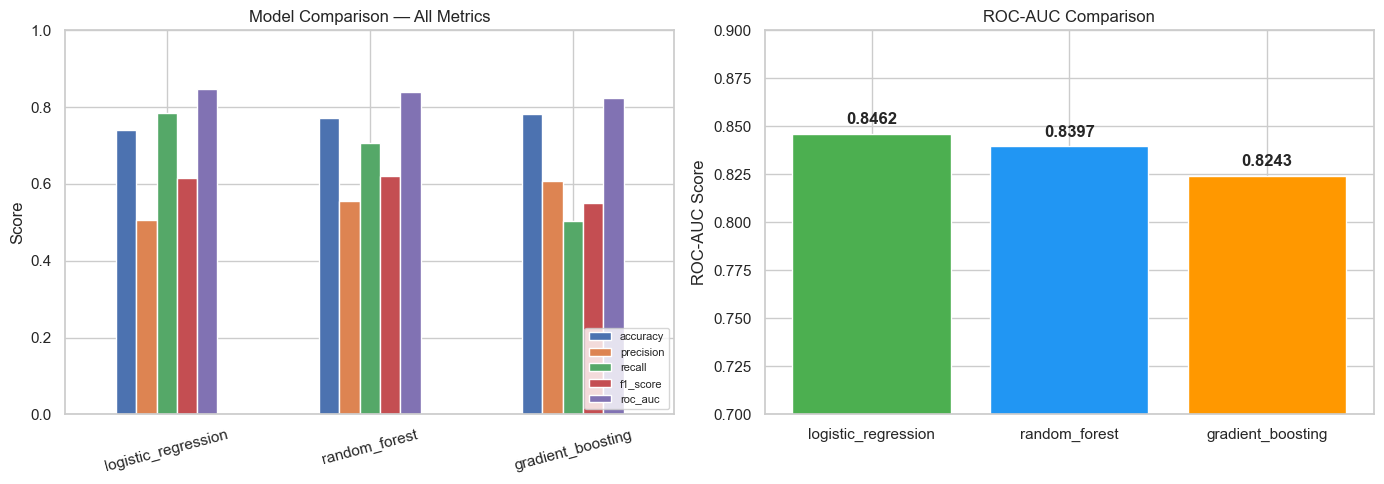

In [35]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all metrics
comparison.plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Model Comparison — All Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=8)

# ROC-AUC comparison
colors = ['#4CAF50', '#2196F3', '#FF9800']
axes[1].bar(comparison.index, comparison['roc_auc'], color=colors[:len(comparison)])
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.7, 0.9)
for i, (name, val) in enumerate(comparison['roc_auc'].items()):
    axes[1].text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Detailed Evaluation of Best Model

In [36]:
# Select best model by ROC-AUC
best_model_name = comparison.index[0]
best_pipeline = trained_pipelines[best_model_name]
print(f'Best model: {best_model_name}\n')

# Predictions
y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Best model: logistic_regression

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



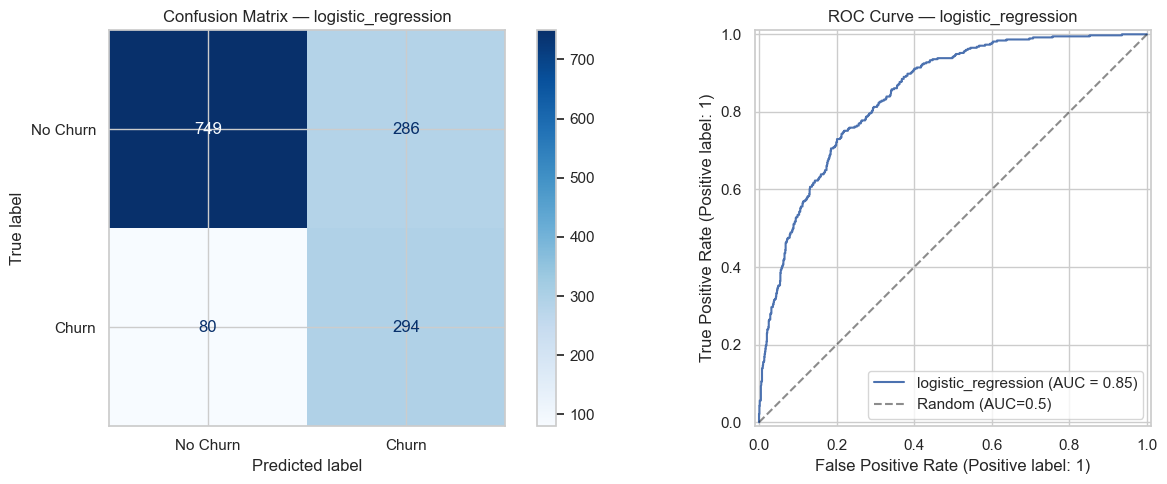

In [37]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_model_name}')

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_best,
    name=best_model_name, ax=axes[1]
)
axes[1].set_title(f'ROC Curve — {best_model_name}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Feature Importance

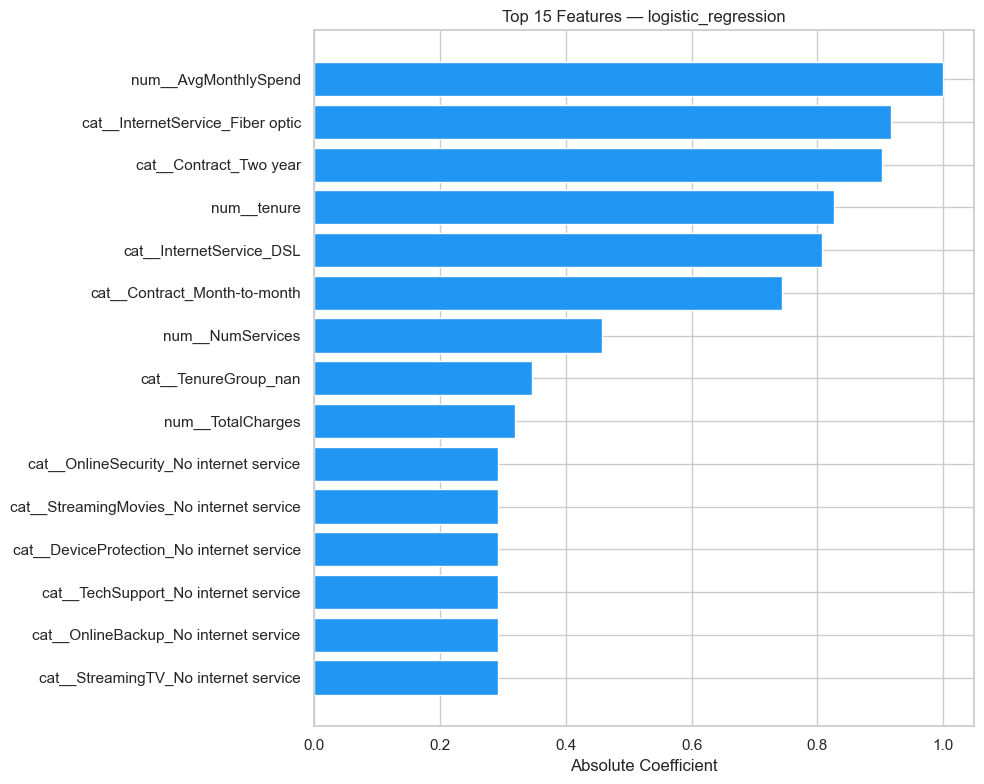

In [38]:
# Extract feature names after preprocessing
preprocessor = best_pipeline.named_steps['preprocessor']
classifier = best_pipeline.named_steps['classifier']

# Get feature names from the fitted transformer
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f'feature_{i}' for i in range(preprocessor.transform(X_test).shape[1])]

# Get importances (works for tree-based and logistic regression)
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    importance_type = 'Feature Importance'
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
    importance_type = 'Absolute Coefficient'
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=True).tail(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_imp['feature'], feat_imp['importance'], color='#2196F3')
    ax.set_xlabel(importance_type)
    ax.set_title(f'Top 15 Features — {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model type.')

## 11. Export Best Model

The best model is saved as a joblib file, ready to be loaded by the FastAPI serving endpoint.

In [41]:
# Save the best model for serving
best_model_path = MODEL_DIR / f'{best_model_name}.joblib'
joblib.dump(best_pipeline, best_model_path)
print(f'Best model saved to: {best_model_path}')
print(f'Model type: {type(best_pipeline)}')
print(f'Pipeline steps: {list(best_pipeline.named_steps.keys())}')

# Save metadata
metadata = {
    'best_model': best_model_name,
    'metrics': all_results[best_model_name],
    'features_numeric': NUMERIC_FEATURES,
    'features_categorical': CATEGORICAL_FEATURES,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
}
with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'\nMetadata saved to: {MODEL_DIR / "model_metadata.json"}')

Best model saved to: e:\Workspace and ideas\churn-prediction-pipeline\models\logistic_regression.joblib
Model type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['preprocessor', 'classifier']

Metadata saved to: e:\Workspace and ideas\churn-prediction-pipeline\models\model_metadata.json


## 12. Test Prediction (Sanity Check)

Verify the saved model works before deploying to FastAPI.

In [42]:
# Load saved model
loaded_pipeline = joblib.load(best_model_path)

# Create a sample high-risk customer
sample_customer = pd.DataFrame([{
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No',
    'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'No', 'StreamingMovies': 'No',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 75.50, 'TotalCharges': 151.0,
}])

# Apply same feature engineering
sample_customer['AvgMonthlySpend'] = sample_customer['TotalCharges'] / (sample_customer['tenure'] + 1)
sample_customer['TenureGroup'] = '0-12m'
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
sample_customer['NumServices'] = sample_customer[service_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

# Predict
pred = loaded_pipeline.predict(sample_customer)[0]
prob = loaded_pipeline.predict_proba(sample_customer)[0][1]

print(f'Sample Customer Prediction:')
print(f'  Churn: {"Yes" if pred == 1 else "No"}')
print(f'  Probability: {prob:.2%}')
print(f'  Risk Level: {"HIGH" if prob >= 0.7 else "MEDIUM" if prob >= 0.4 else "LOW"}')
print(f'\n✅ Model is working correctly and ready for FastAPI serving.')

Sample Customer Prediction:
  Churn: Yes
  Probability: 86.95%
  Risk Level: HIGH

✅ Model is working correctly and ready for FastAPI serving.


## Next Steps

1. **Start the API**: `uvicorn src.serve:app --reload` (from project root)
2. **View MLflow UI**: `mlflow ui --port 5000`
3. **Docker deployment**: `docker build -t churn-api . && docker run -p 8000:8000 churn-api`
4. **API docs**: Visit `http://localhost:8000/docs` for interactive Swagger UI